# Screening fraudulent job postings: rules vs. machine learning under a review budget

**Business question.** A job board's trust & safety team can only manually review a small share of new postings.
Which postings should they review first, and how much fraud does each approach catch for the same review effort?

**Data.** EMSCAD / "Real or Fake Job Posting" dataset: 17,880 postings, 866 labelled fraudulent (4.8%).
See `data/README.md` for how to download it.

**Approach.**
1. Profile where fraud concentrates (data-quality gaps turn out to be the strongest signal).
2. Build a transparent SQL rule baseline in DuckDB and measure each rule's precision, recall and alert volume.
3. Train two models (TF-IDF + metadata logistic regression, and LightGBM), select with 5-fold CV on the training set,
   and evaluate once on a held-out 20% test set.
4. Compare rules and models *at equal review volume* and pick an operating point for a fixed daily review budget.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, duckdb, matplotlib.pyplot as plt, seaborn as sns
from scipy import sparse
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import lightgbm as lgb

SEED = 42
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid")
df = pd.read_csv("data/fake_job_postings.csv")
df["country"] = df["location"].fillna("").str.split(",").str[0].str.strip().replace("", "Unknown")
import re
_norm = lambda x: re.sub(r"\W+", " ", str(x).lower())[:300]
# A "poster" = the company profile text when present, otherwise the description text.
# Copies of the same posting (400 of 866 fraud cases share a description) must never straddle train and test.
df["poster"] = np.where(df.company_profile.notna(), "c:" + df.company_profile.map(_norm), "d:" + df.description.map(_norm))
print(df.shape, "fraud rate:", round(df.fraudulent.mean(), 4), "| distinct posters:", df.poster.nunique())

(17880, 20) fraud rate: 0.0484 | distinct posters: 4422


## 1. Hold out unseen posters before looking at anything
Many fraudulent postings are near-copies from the same few scam operations. A random split would put copies of the
same scam in both train and test, and the model would simply memorise company names. Instead, the split is
**grouped by poster**, so the 20% test set contains only companies the model has never seen: the realistic case of a new scammer.
All exploration and rule design below uses the training set only.

In [2]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
tr_idx, te_idx = next(sgkf.split(df, df.fraudulent, groups=df.poster))
train, test = df.iloc[tr_idx].copy(), df.iloc[te_idx].copy()
assert set(train.poster).isdisjoint(test.poster)
print(f"train {len(train):,} ({train.fraudulent.sum()} fraud) | test {len(test):,} ({test.fraudulent.sum()} fraud) | shared posters: 0")

train 14,304 (693 fraud) | test 3,576 (173 fraud) | shared posters: 0


## 2. Where does fraud concentrate? (training set)
Missing information is the loudest signal: postings without a company logo or company profile are fraudulent
far more often than the base rate.

In [3]:
def rate_by(col, min_n=50):
    g = train.groupby(train[col].fillna("Missing") if train[col].dtype == object else train[col]).fraudulent.agg(fraud_rate="mean", postings="size")
    return g[g.postings >= min_n].sort_values("fraud_rate", ascending=False)

missing = pd.DataFrame({
    c: {"fraud rate if missing": train[train[c].isna()].fraudulent.mean(),
        "fraud rate if present": train[train[c].notna()].fraudulent.mean(),
        "share missing": train[c].isna().mean()}
    for c in ["company_profile", "requirements", "benefits", "salary_range", "department"]}).T
display(missing)
display(rate_by("has_company_logo"))
display(rate_by("industry").head(8))
display(rate_by("country", 100).head(6))

,fraud rate if missing,fraud rate if present,share missing
company_profile,0.176,0.020,0.184
requirements,0.056,0.047,0.161
benefits,0.049,0.048,0.431
salary_range,0.045,0.066,0.838
department,0.048,0.049,0.638


,fraud_rate,postings
has_company_logo,,
0,0.153,3023
1,0.020,11281


,fraud_rate,postings
industry,,
Accounting,0.301,133
"Leisure, Travel & Tourism",0.296,71
Real Estate,0.287,80
Oil & Energy,0.260,235
Hospitality,0.139,72
"Health, Wellness and Fitness",0.103,107
Hospital & Health Care,0.096,436
Staffing and Recruiting,0.090,89


,fraud_rate,postings
country,,
AU,0.195,174
US,0.069,8339
Unknown,0.049,285
CA,0.023,311
IN,0.016,247
GB,0.011,1932


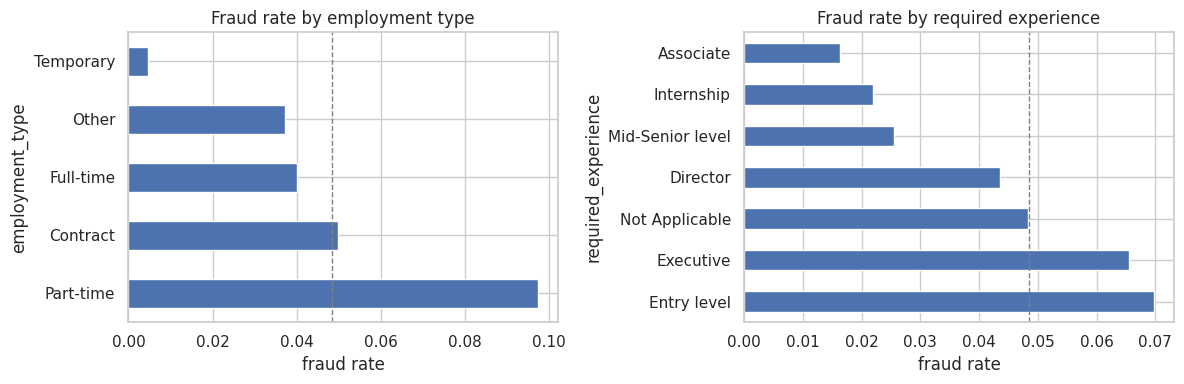

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rate_by("employment_type").fraud_rate.plot.barh(ax=axes[0], color="#4C72B0"); axes[0].set_title("Fraud rate by employment type")
rate_by("required_experience").fraud_rate.plot.barh(ax=axes[1], color="#4C72B0"); axes[1].set_title("Fraud rate by required experience")
for a in axes: a.axvline(train.fraudulent.mean(), color="grey", ls="--", lw=1); a.set_xlabel("fraud rate")
plt.tight_layout(); plt.savefig("images/fraud_rate_segments.png", dpi=120); plt.show()

## 3. Transparent rule baseline (SQL in DuckDB)
Rules live in `sql/rules.sql`. For each rule: how many postings it flags (review workload), what share of flags
are fraud (precision), and what share of all fraud it catches (recall). Measured on the **training** set, where rules were designed.

In [5]:
con = duckdb.connect()
def score_rules(frame):
    con.register("postings", frame)
    con.execute(open("sql/rules.sql").read())
    flags = con.execute("SELECT * FROM rule_flags").df()
    rows = []
    rule_cols = [c for c in flags.columns if re.match(r"r\d+_", c)]
    for r in rule_cols:
        f = flags[r].fillna(False).astype(bool)
        rows.append({"rule": r, "flagged": int(f.sum()), "flag_rate": f.mean(),
                     "precision": flags.fraudulent[f].mean(), "recall": flags.fraudulent[f].sum() / flags.fraudulent.sum()})
    anyf = flags[rule_cols].fillna(False).astype(bool).any(axis=1)
    rows.append({"rule": "ANY rule fires", "flagged": int(anyf.sum()), "flag_rate": anyf.mean(),
                 "precision": flags.fraudulent[anyf].mean(), "recall": flags.fraudulent[anyf].sum() / flags.fraudulent.sum()})
    return pd.DataFrame(rows).set_index("rule"), flags
rules_train, _ = score_rules(train)
display(rules_train)

,flagged,flag_rate,precision,recall
rule,,,,
r1_no_logo_no_profile,2081,0.145,0.218,0.654
r2_no_logo_no_screening_qs,2242,0.157,0.169,0.547
r3_high_risk_industry,368,0.026,0.274,0.146
r4_remote_entry_no_logo,58,0.004,0.483,0.040
r5_low_edu_with_salary_bait,416,0.029,0.180,0.108
r6_scam_phrasing,619,0.043,0.289,0.258
ANY rule fires,3812,0.266,0.147,0.807


## 4. Models: TF-IDF text + structured metadata (5-fold CV, grouped by poster)
Features: TF-IDF on title/company profile/description/requirements/benefits (word 1–2-grams),
one-hot metadata (employment type, experience, education, industry, function, country), and missing-field flags.

In [6]:
TEXT = ["title", "company_profile", "description", "requirements", "benefits"]
CATS = ["employment_type", "required_experience", "required_education", "industry", "function", "country"]
FLAGS = ["telecommuting", "has_company_logo", "has_questions"]
MISS = ["company_profile", "requirements", "benefits", "salary_range", "department"]

def text_of(f): return f[TEXT].fillna("").agg(" ".join, axis=1)
def fit_features(tr):
    tf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000, sublinear_tf=True, stop_words="english").fit(text_of(tr))
    oh = OneHotEncoder(handle_unknown="ignore", min_frequency=20).fit(tr[CATS].fillna("Missing"))
    return tf, oh
def transform(f, tf, oh):
    num = np.column_stack([f[FLAGS].values, f[MISS].isna().values.astype(int)])
    return sparse.hstack([tf.transform(text_of(f)), oh.transform(f[CATS].fillna("Missing")), sparse.csr_matrix(num)]).tocsr()

MODELS = {
    "logistic_regression": lambda: LogisticRegression(C=4.0, class_weight="balanced", max_iter=3000),
    "lightgbm": lambda: lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, subsample=0.8, subsample_freq=1,
                                           colsample_bytree=0.3, scale_pos_weight=5, random_state=SEED, verbose=-1),
}
skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
cv = {m: [] for m in MODELS}
for tr_i, va_i in skf.split(train, train.fraudulent, groups=train.poster):
    tr, va = train.iloc[tr_i], train.iloc[va_i]
    tf, oh = fit_features(tr); Xtr, Xva = transform(tr, tf, oh), transform(va, tf, oh)
    for m, mk in MODELS.items():
        p = mk().fit(Xtr, tr.fraudulent).predict_proba(Xva)[:, 1]
        cv[m].append((roc_auc_score(va.fraudulent, p), average_precision_score(va.fraudulent, p)))
cv_tbl = pd.DataFrame({m: {"ROC-AUC mean": np.mean([a for a, _ in v]), "ROC-AUC sd": np.std([a for a, _ in v]),
                           "PR-AUC mean": np.mean([b for _, b in v]), "PR-AUC sd": np.std([b for _, b in v])} for m, v in cv.items()}).T
display(cv_tbl)
best = cv_tbl["PR-AUC mean"].idxmax(); print("selected on CV PR-AUC:", best)

,ROC-AUC mean,ROC-AUC sd,PR-AUC mean,PR-AUC sd
logistic_regression,0.917,0.030,0.663,0.090
lightgbm,0.911,0.042,0.663,0.118


selected on CV PR-AUC: lightgbm


PR-AUC (average precision) is the primary metric: with 4.8% fraud, ROC-AUC looks flattering because it rewards
ranking the huge pool of legitimate postings correctly. PR-AUC measures how clean the review queue is.

## 5. One-time evaluation on the held-out test set

In [7]:
tf, oh = fit_features(train)
Xtr, Xte = transform(train, tf, oh), transform(test, tf, oh)
final = {m: mk().fit(Xtr, train.fraudulent) for m, mk in MODELS.items()}
p_test = {m: mod.predict_proba(Xte)[:, 1] for m, mod in final.items()}
test_tbl = pd.DataFrame({m: {"ROC-AUC": roc_auc_score(test.fraudulent, p), "PR-AUC": average_precision_score(test.fraudulent, p)}
                         for m, p in p_test.items()}).T
display(test_tbl)

,ROC-AUC,PR-AUC
logistic_regression,0.979,0.837
lightgbm,0.975,0.842


### How much would a random split have overstated performance?
Same logistic regression, but trained and tested on a plain random 80/20 split, where copies of the same scam land on both sides.

In [8]:
r_tr, r_te = train_test_split(df, test_size=0.2, stratify=df.fraudulent, random_state=SEED)
r_tf, r_oh = fit_features(r_tr)
p_rand = MODELS["logistic_regression"]().fit(transform(r_tr, r_tf, r_oh), r_tr.fraudulent).predict_proba(transform(r_te, r_tf, r_oh))[:, 1]
leak = pd.DataFrame({"random split (seen posters)": {"PR-AUC": average_precision_score(r_te.fraudulent, p_rand), "ROC-AUC": roc_auc_score(r_te.fraudulent, p_rand)},
                     "grouped split (unseen posters)": {"PR-AUC": test_tbl.loc["logistic_regression", "PR-AUC"], "ROC-AUC": test_tbl.loc["logistic_regression", "ROC-AUC"]}}).T
display(leak)

,PR-AUC,ROC-AUC
random split (seen posters),0.957,0.994
grouped split (unseen posters),0.837,0.979


## 6. The decision: what does a fixed review budget buy?
If reviewers can check the top *k*% of postings ranked by risk, how much fraud do they catch and how clean is the queue?
Rules are compared at the review volume they actually generate.

In [9]:
y = test.fraudulent.values
def at_budget(p, share):
    k = int(round(share * len(p))); idx = np.argsort(-p)[:k]
    return {"reviews": k, "precision": y[idx].mean(), "recall": y[idx].sum() / y.sum()}
budget = pd.DataFrame({f"top {int(s*100)}%": at_budget(p_test[best], s) for s in [0.02, 0.05, 0.10]}).T
display(budget)

rules_test, flags_test = score_rules(test)
anyrule = rules_test.loc["ANY rule fires"]
model_same_volume = at_budget(p_test[best], anyrule.flag_rate)
cmp_tbl = pd.DataFrame({"Rules (any fires)": {"reviews": int(anyrule.flagged), "precision": anyrule.precision, "recall": anyrule.recall},
                        f"{best} at same volume": model_same_volume}).T
display(cmp_tbl)

,reviews,precision,recall
top 2%,72.0,0.972,0.405
top 5%,179.0,0.743,0.769
top 10%,358.0,0.444,0.919


,reviews,precision,recall
Rules (any fires),720.0,0.226,0.942
lightgbm at same volume,720.0,0.231,0.960


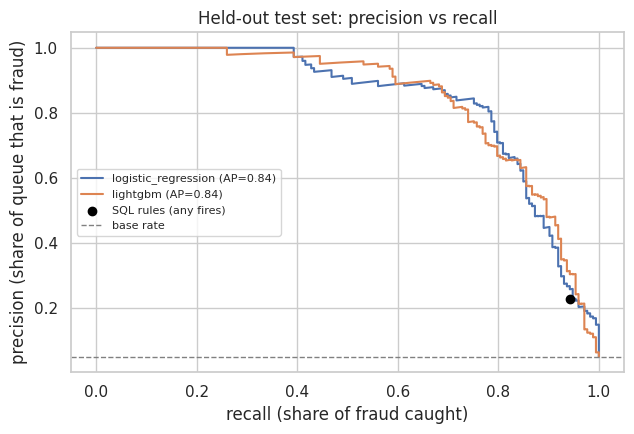

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for m, p in p_test.items():
    pr, rc, _ = precision_recall_curve(y, p); ax.plot(rc, pr, label=f"{m} (AP={average_precision_score(y, p):.2f})")
ax.scatter([anyrule.recall], [anyrule.precision], color="black", zorder=5, label="SQL rules (any fires)")
ax.axhline(y.mean(), color="grey", ls="--", lw=1, label="base rate")
ax.set_xlabel("recall (share of fraud caught)"); ax.set_ylabel("precision (share of queue that is fraud)")
ax.set_title("Held-out test set: precision vs recall"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("images/pr_curve_test.png", dpi=120); plt.show()

## 7. What drives the logistic regression's risk score?

In [11]:
lr = final["logistic_regression"]
names = np.concatenate([tf.get_feature_names_out(), oh.get_feature_names_out(CATS), np.array(FLAGS + [f"missing_{c}" for c in MISS])])
coef = pd.Series(lr.coef_[0], index=names).sort_values()
display(pd.DataFrame({"pushes toward FRAUD": coef.tail(15)[::-1].index, "pushes toward LEGIT": coef.head(15).index}))

,pushes toward FRAUD,pushes toward LEGIT
0,using link,industry_Restaurants
1,apply using,growing
2,money,employment_type_Temporary
3,earn,industry_Internet
4,link,country_GR
5,line requirements,client
6,accion,function_Health Care Provider
7,administrative,experience
8,assistant,companies
9,data entry,nbsp


## 8. Error analysis: fraud the model misses in its top-5% queue

In [12]:
k = int(round(0.05 * len(test))); flagged = np.zeros(len(test), bool); flagged[np.argsort(-p_test[best])[:k]] = True
missed = test[(y == 1) & ~flagged]
print(f"fraud postings outside the top-5% queue: {len(missed)} of {y.sum()}")
display(pd.DataFrame({
    "missed fraud": missed[["has_company_logo", "telecommuting"]].mean().tolist() + [missed.company_profile.notna().mean()],
    "caught fraud": test[(y == 1) & flagged][["has_company_logo", "telecommuting"]].mean().tolist() + [test[(y == 1) & flagged].company_profile.notna().mean()]},
    index=["has company logo", "telecommuting", "has company profile"]))

fraud postings outside the top-5% queue: 40 of 173


,missed fraud,caught fraud
has company logo,0.625,0.218
telecommuting,0.100,0.023
has company profile,0.575,0.211
